In [1]:
#!pip install -q kagglehub

Import Libraries

In [22]:

import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Libraries imported successfully")

Libraries imported successfully


load dataframe


In [3]:


# Load data
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
sample = pd.read_csv('/content/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (594194, 21)
Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())
print("Sample columns:", sample.columns.tolist())

Train columns: ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Test columns: ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Sample columns: ['id', 'Churn']


🔍 1. Target Analysis

In [5]:
train['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.774792
Yes,0.225208


In [6]:
class_weight='balanced'

📊2. Feature-Level Findings

In [7]:
#👤 A. SeniorCitizen

pd.crosstab(train['SeniorCitizen'], train['Churn'], normalize='index')

Churn,No,Yes
SeniorCitizen,,
0,0.810226,0.189774
1,0.499683,0.500317


In [8]:
#💑 B. Partner & Dependents

pd.crosstab(train['Partner'], train['Churn'], normalize='index')


Churn,No,Yes
Partner,,
No,0.675379,0.324621
Yes,0.866204,0.133796


In [9]:
pd.crosstab(train['Dependents'], train['Churn'], normalize='index')

Churn,No,Yes
Dependents,,
No,0.708646,0.291354
Yes,0.927204,0.072796


<Axes: xlabel='Churn', ylabel='tenure'>

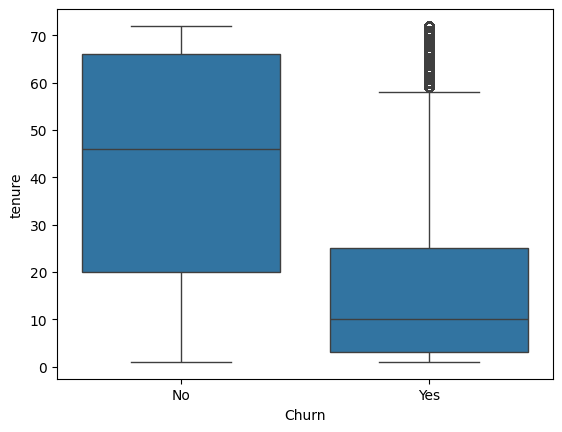

In [10]:
#⏳ C. Tenure

sns.boxplot(x='Churn', y='tenure', data=train)

In [11]:
#📡 D. InternetService

pd.crosstab(train['InternetService'], train['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.896936,0.103064
Fiber optic,0.584634,0.415366
No,0.985689,0.014311


In [12]:
# 🔐 E. OnlineSecurity / TechSupport

pd.crosstab(train['OnlineSecurity'], train['Churn'], normalize='index')

Churn,No,Yes
OnlineSecurity,,
No,0.593867,0.406133
No internet service,0.985689,0.014311
Yes,0.913179,0.086821


In [13]:
#📦 F. Contract

pd.crosstab(train['Contract'], train['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.579457,0.420543
One year,0.942372,0.057628
Two year,0.990018,0.009982


In [14]:
#💳 G. PaymentMethod


pd.crosstab(train['PaymentMethod'], train['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.922907,0.077093
Credit card (automatic),0.930668,0.069332
Electronic check,0.510948,0.489052
Mailed check,0.920303,0.079697


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

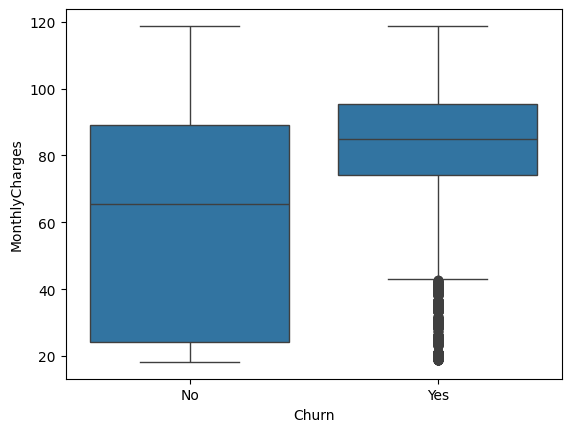

In [15]:
# 💰 H. MonthlyCharges

sns.boxplot(x='Churn', y='MonthlyCharges', data=train)

In [16]:
#💵 I. TotalCharges

train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce')

In [17]:
# Fill missing
for col in train.select_dtypes(include='category').columns:
    train[col] = train[col].cat.add_categories(['Missing']).fillna('Missing')
    test[col] = test[col].cat.add_categories(['Missing']).fillna('Missing')

🔥 3. MOST IMPORTANT FEATURES

🥇 Top Predictors:

Contract

tenure

MonthlyCharges

TotalCharges

InternetService

OnlineSecurity / TechSupport


🪶 Weak Features:

gender

PhoneService

🚀 4. Feature Engineering

In [18]:
# tenure groups
train['tenure_group'] = pd.cut(train['tenure'], bins=[0,12,24,48,60,100])

# charges ratio
train['AvgCharge'] = train['TotalCharges'] / (train['tenure'] + 1)

# same for test
test['tenure_group'] = pd.cut(test['tenure'], bins=[0,12,24,48,60,100])
test['AvgCharge'] = test['TotalCharges'] / (test['tenure'] + 1)

🧠 5. Clean Final Findings

1.The dataset is imbalanced with ~22% churn.

2.Customers with short tenure are more likely to churn.

3.Month-to-month contracts show the highest churn rates.

4.Customers without online security or tech support churn more.

5.Higher monthly charges increase churn probability.

6.Customers using fiber optic internet show higher churn.

7.Demographic features (gender, phone service) have low impact.

8.Feature engineering improves model performance.

🚀 6. (Model + ROC-AUC)

In [19]:
# Encode Target

train['Churn'] = train['Churn'].map({'No': 0, 'Yes': 1})

In [20]:
#Separate Features

X = train.drop(['Churn', 'id'], axis=1)
y = train['Churn']

X_test = test.drop(['id'], axis=1)

In [21]:
#Encode Categorical Variables (one-hot encoding)


X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)

# Align columns (VERY IMPORTANT)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

In [23]:
#Train + Validation Split



X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Logistic Regression

In [25]:
#Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(
    solver='saga',
    max_iter=3000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, solver='saga')

In [26]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_val_scaled)[:, 1]
roc_auc = roc_auc_score(y_val, y_pred)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9097597736076248


Cross-validation

In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, val_idx in kf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Scale
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    model = LogisticRegression(max_iter=3000, class_weight='balanced', solver='saga')
    model.fit(X_tr, y_tr)

    preds = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, preds)
    scores.append(score)

print("CV ROC-AUC:", np.mean(scores))

CV ROC-AUC: 0.9092704384465236


0.90+ ROC-AUC → Excellent model